In [2]:
# =========================================================
# INSTALL PACKAGES
# =========================================================

packages <- c(
  "tidyverse",
  "psych",
  "nFactors",
  "GPArotation",
  "corrplot",
  "readr"
)

installed <- rownames(installed.packages())

for(pkg in packages){
  if(!pkg %in% installed){
    install.packages(pkg, dependencies = TRUE)
  }
}

lapply(packages, library, character.only = TRUE)


Anexando pacote: 'psych'


Os seguintes objetos são mascarados por 'package:ggplot2':

    %+%, alpha



Anexando pacote: 'GPArotation'


Os seguintes objetos são mascarados por 'package:psych':

    equamax, varimin


corrplot 0.95 loaded



[[1]]
 [1] "stringr"   "dplyr"     "purrr"     "readr"     "tidyr"     "tibble"   
 [7] "ggplot2"   "tidyverse" "stats"     "graphics"  "grDevices" "utils"    
[13] "datasets"  "methods"   "base"     

[[2]]
 [1] "psych"     "stringr"   "dplyr"     "purrr"     "readr"     "tidyr"    
 [7] "tibble"    "ggplot2"   "tidyverse" "stats"     "graphics"  "grDevices"
[13] "utils"     "datasets"  "methods"   "base"     

[[3]]
 [1] "nFactors"  "psych"     "stringr"   "dplyr"     "purrr"     "readr"    
 [7] "tidyr"     "tibble"    "ggplot2"   "tidyverse" "stats"     "graphics" 
[13] "grDevices" "utils"     "datasets"  "methods"   "base"     

[[4]]
 [1] "GPArotation" "nFactors"    "psych"       "stringr"     "dplyr"      
 [6] "purrr"       "readr"       "tidyr"       "tibble"      "ggplot2"    
[11] "tidyverse"   "stats"       "graphics"    "grDevices"   "utils"      
[16] "datasets"    "methods"     "base"       

[[5]]
 [1] "corrplot"    "GPArotation" "nFactors"    "psych"       "stringr"    
 [6] "dplyr"       "purrr"       "readr"       "tidyr"       "tibble"     
[11] "ggplot2"     "tidyverse"   "stats"       "graphics"    "grDevices"  
[16] "utils"       "datasets"    "methods"     "base"       

[[6]]
 [1] "corrplot"    "GPArotation" "nFactors"    "psych"       "stringr"    
 [6] "dplyr"       "purrr"       "readr"       "tidyr"       "tibble"     
[11] "ggplot2"     "tidyverse"   "stats"       "graphics"    "grDevices"  
[16] "utils"       "datasets"    "methods"     "base"

In [3]:
install.packages("knitr")

Instalando pacote em 'C:/Users/Maxwell/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)



package 'knitr' successfully unpacked and MD5 sums checked

Os pacotes binários baixados estão em
	C:\Users\Maxwell\AppData\Local\Temp\RtmpCicWPb\downloaded_packages


In [4]:
library(knitr)

In [10]:
# =========================================================
# IMPORT DATA
# =========================================================

efa_data_raw <- read.delim(
  "adequacy-c.txt",
  check.names = FALSE
)

names(efa_data_raw) <- gsub(
  "\\.+",
  "_",
  names(efa_data_raw)
)

### Preparar matriz para EFA

In [11]:
# =========================================================
# NUMERIC VARIABLES
# =========================================================

efa_data <- efa_data_raw %>%
  select(where(is.numeric)) %>%
  select(-Version_Year)

# imputação simples
efa_data <- efa_data %>%
  mutate(
    across(
      everything(),
      ~ ifelse(
        is.na(.),
        median(., na.rm = TRUE),
        .
      )
    )
  )

### Correlação Spearman

In [12]:
# =========================================================
# CORRELATION MATRIX
# =========================================================

cor_mat <- cor(
  efa_data,
  method = "spearman"
)

### 1. PARALLEL ANALYSIS

Parallel analysis suggests that the number of factors =  5  and the number of components =  NA 


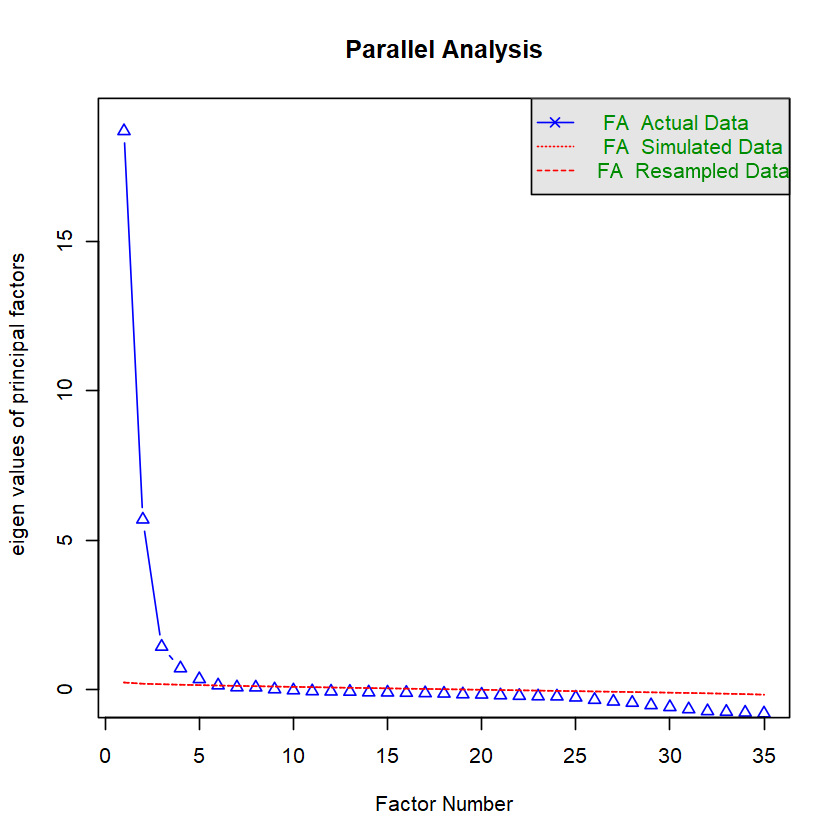

In [13]:
# =========================================================
# PARALLEL ANALYSIS
# =========================================================

set.seed(123)

fa.parallel(
  efa_data,
  fa = "fa",
  fm = "minres",
  cor = "cor",
  n.iter = 500,
  main = "Parallel Analysis"
)

### 2. VSS + MAP


Very Simple Structure
Call: vss(x = x, n = n, rotate = rotate, diagonal = diagonal, fm = fm, 
    n.obs = n.obs, plot = plot, title = title, use = use, cor = cor)
VSS complexity 1 achieves a maximimum of 0.88  with  1  factors
VSS complexity 2 achieves a maximimum of 0.93  with  2  factors

The Velicer MAP achieves a minimum of 0.03  with  5  factors 
BIC achieves a minimum of  13122.64  with  6  factors
Sample Size adjusted BIC achieves a minimum of  14393.6  with  6  factors

Statistics by number of factors 
  vss1 vss2   map dof chisq prob sqresid  fit RMSEA   BIC SABIC complex eChisq
1 0.88 0.00 0.103 560 82803    0      50 0.88  0.22 78310 80090     1.0  60091
2 0.87 0.93 0.048 526 46719    0      30 0.93  0.17 42499 44170     1.1   6408
3 0.56 0.71 0.034 493 35017    0     109 0.74  0.15 31062 32628     1.3   2749
4 0.46 0.74 0.029 461 28206    0     105 0.75  0.14 24508 25973     1.5   1290
5 0.46 0.73 0.027 430 21870    0     104 0.75  0.13 18420 19787     1.5    764
6 0.41 0.

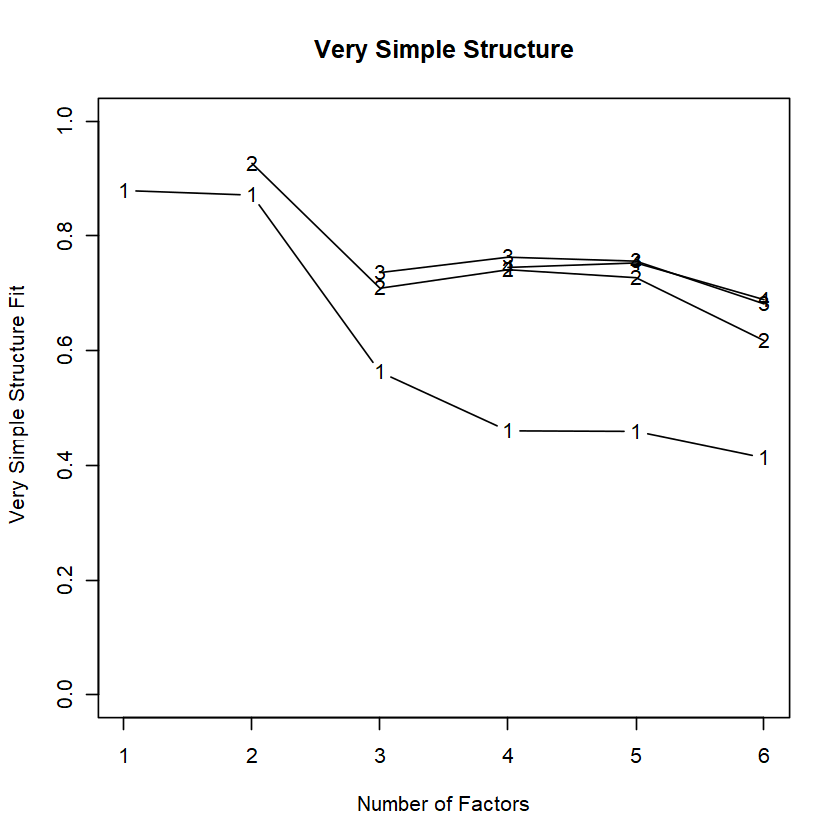

In [16]:
# =========================================================
# VSS + MAP
# =========================================================

vss_results <- VSS(
  efa_data,
  n = 6,
  rotate = "promax",
  fm = "minres",
  plot = TRUE
)

vss_results

In [17]:
# =========================================================
# MAP
# =========================================================

print(as.matrix(vss_results$map))

           [,1]
[1,] 0.10284370
[2,] 0.04753766
[3,] 0.03417353
[4,] 0.02858660
[5,] 0.02746648
[6,] 0.02746799


In [18]:
# =========================================================
# VSS
# =========================================================

tabela_vss <- data.frame(
  vss1 = vss_results$cfit.1, 
  vss2 = vss_results$cfit.2
)
print(tabela_vss)

       vss1      vss2
1 0.8793049 0.0000000
2 0.8712548 0.9266586
3 0.5626797 0.7088803
4 0.4601330 0.7411817
5 0.4591860 0.7272598
6 0.4130973 0.6175979


### 3. Scree Plot

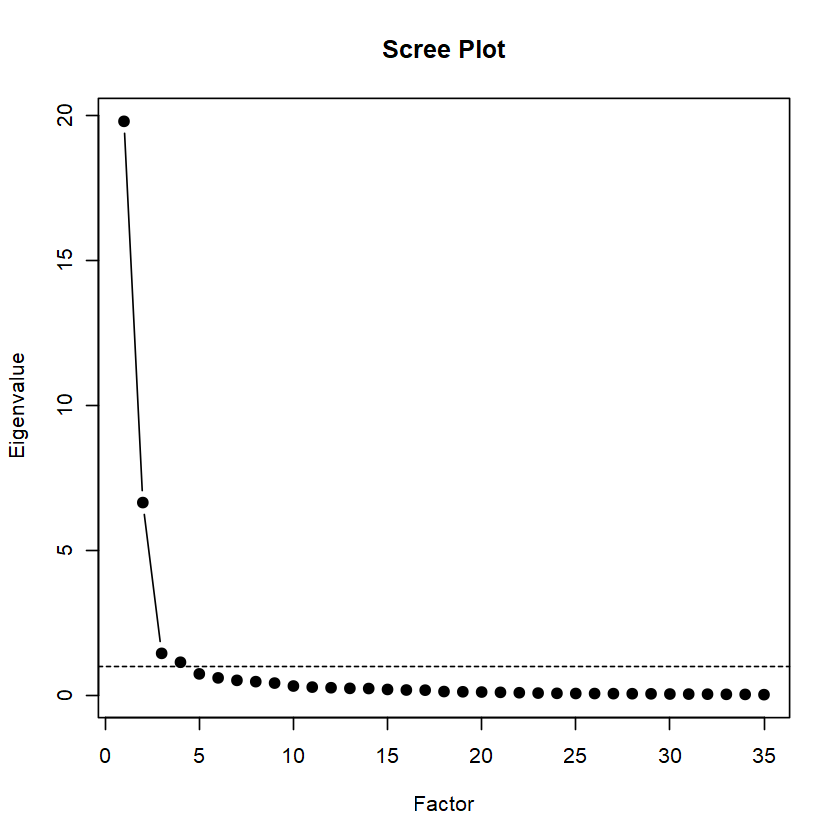

In [19]:
# =========================================================
# SCREE PLOT
# =========================================================

eigen_values <- eigen(cor_mat)$values

plot(
  eigen_values,
  type = "b",
  pch = 19,
  xlab = "Factor",
  ylab = "Eigenvalue",
  main = "Scree Plot"
)

abline(h = 1, lty = 2)

### 4. Kaiser Criterion

In [20]:
# =========================================================
# KAISER
# =========================================================

sum(eigen_values > 1)

[1] 4

### 5. Eigenvalues Table

In [25]:
# =========================================================
# EIGENVALUES
# =========================================================

ev <- eigen(cor_mat)$values
print(head(eigen_table, 10))

# A tibble: 10 × 3
   factor eigenvalue cumulative
    <int>      <dbl>      <dbl>
 1      1     19.8        0.566
 2      2      6.65       0.756
 3      3      1.45       0.797
 4      4      1.14       0.830
 5      5      0.742      0.851
 6      6      0.604      0.869
 7      7      0.519      0.883
 8      8      0.474      0.897
 9      9      0.425      0.909
10     10      0.323      0.918


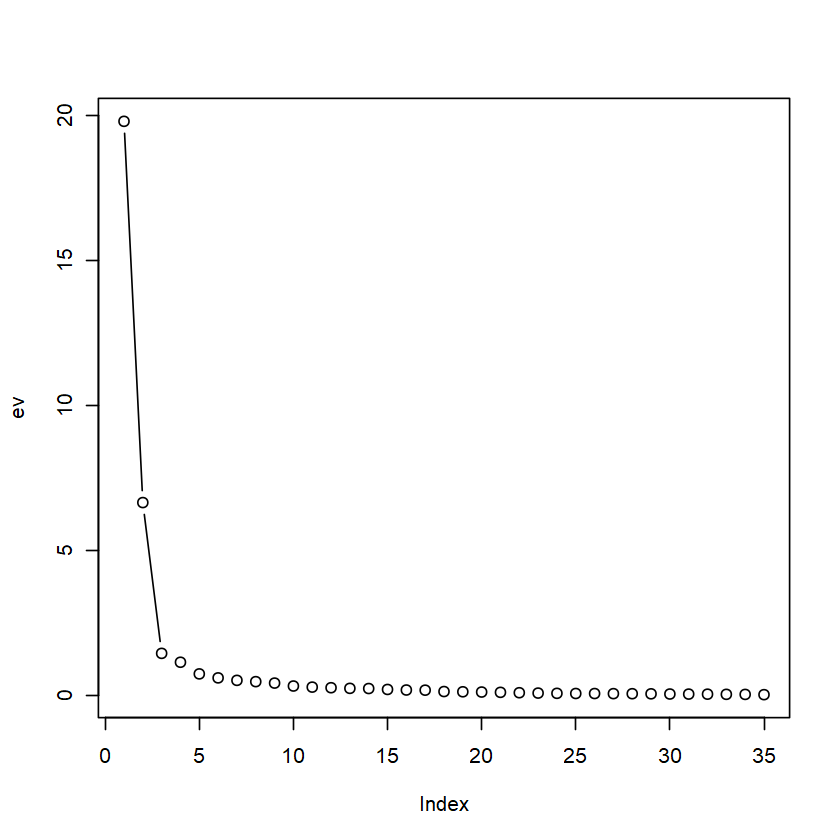

In [26]:
plot(ev, type="b")

### 6. Parallel Analysis por Ano


YEAR: 2017 
Parallel analysis suggests that the number of factors =  5  and the number of components =  NA 

YEAR: 2019 


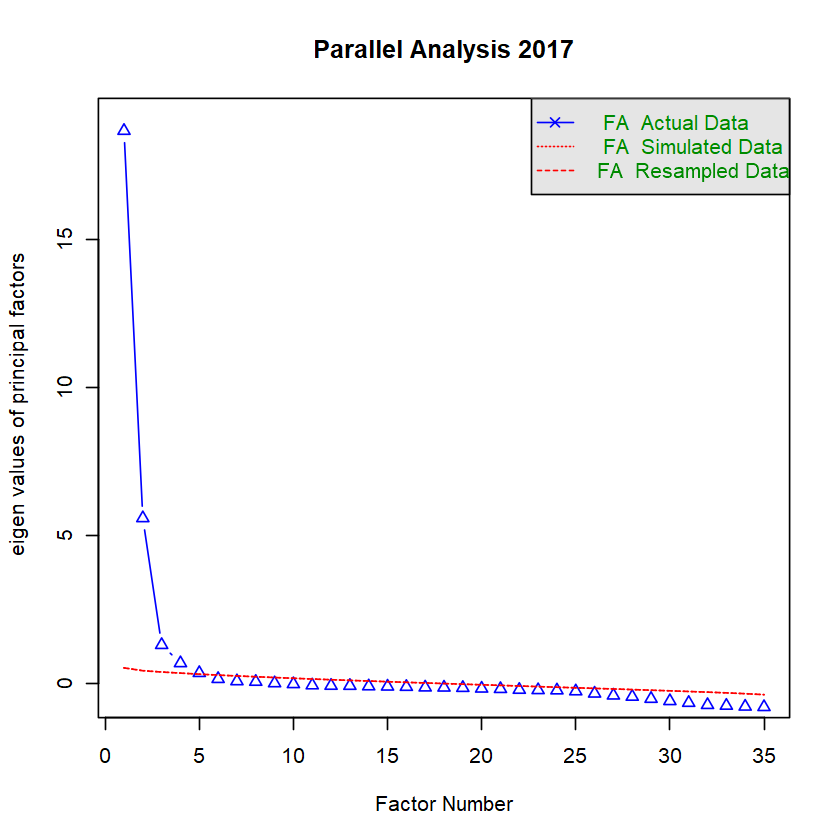

Parallel analysis suggests that the number of factors =  4  and the number of components =  NA 

YEAR: 2021 


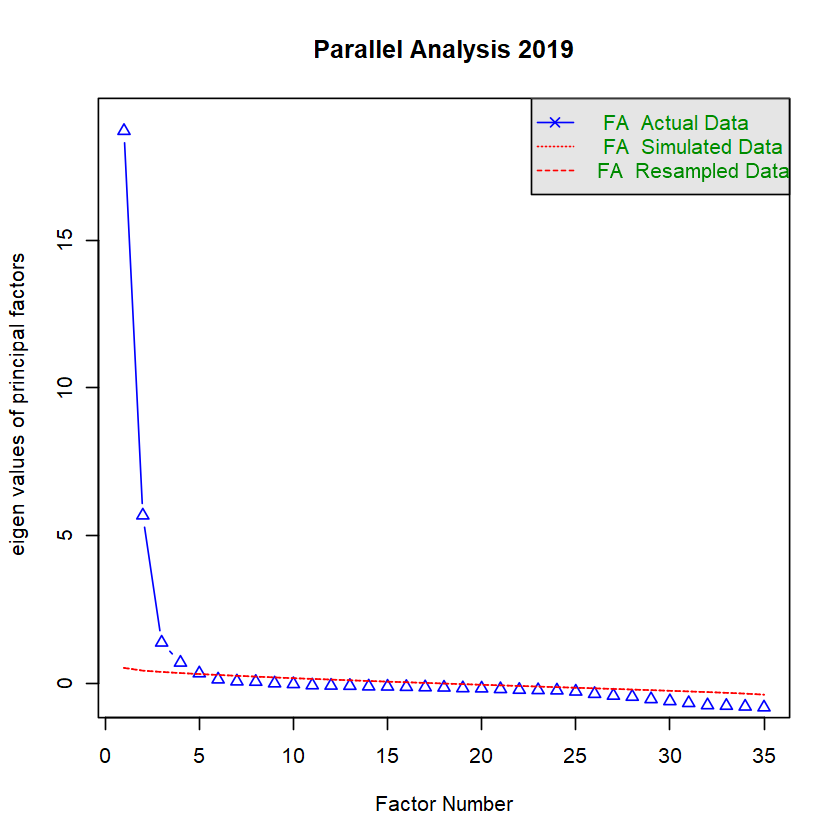

Parallel analysis suggests that the number of factors =  4  and the number of components =  NA 

YEAR: 2023 


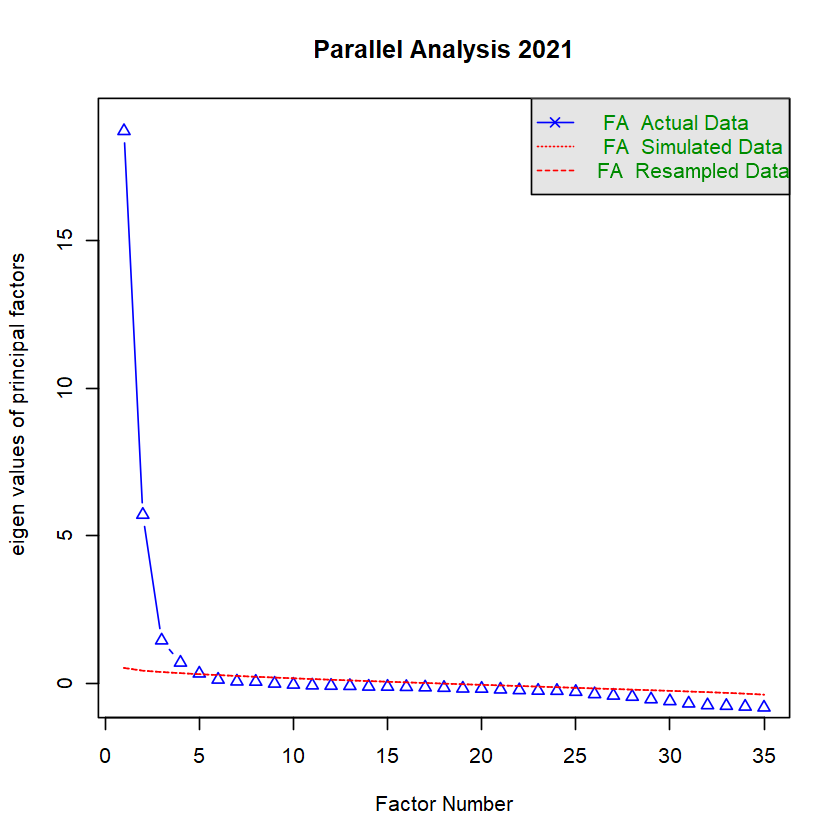

Parallel analysis suggests that the number of factors =  4  and the number of components =  NA 

YEAR: 2025 


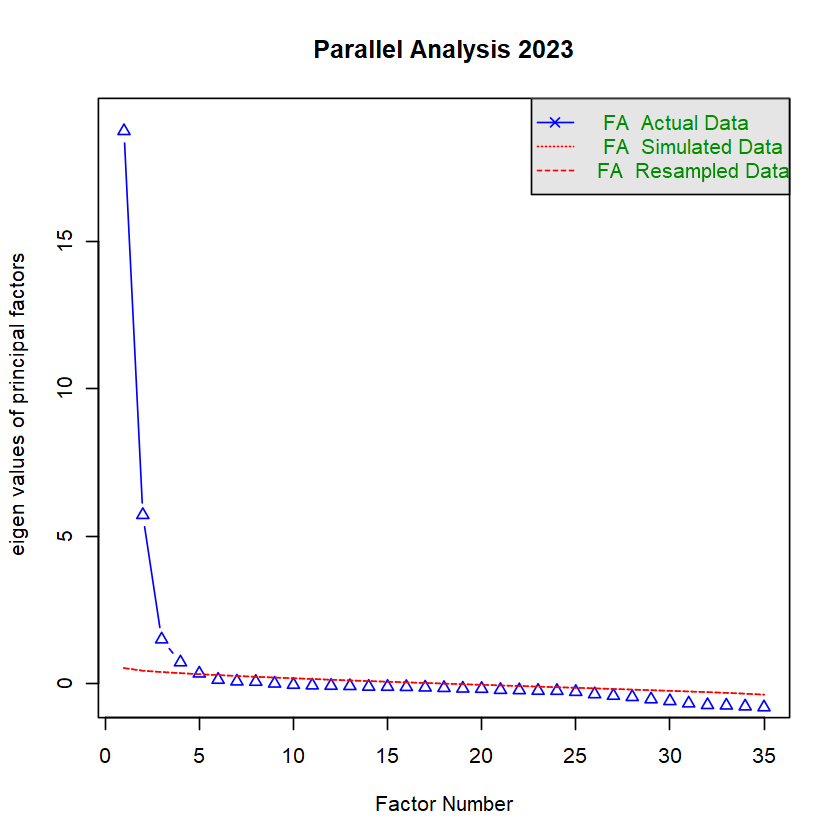

Parallel analysis suggests that the number of factors =  4  and the number of components =  NA 


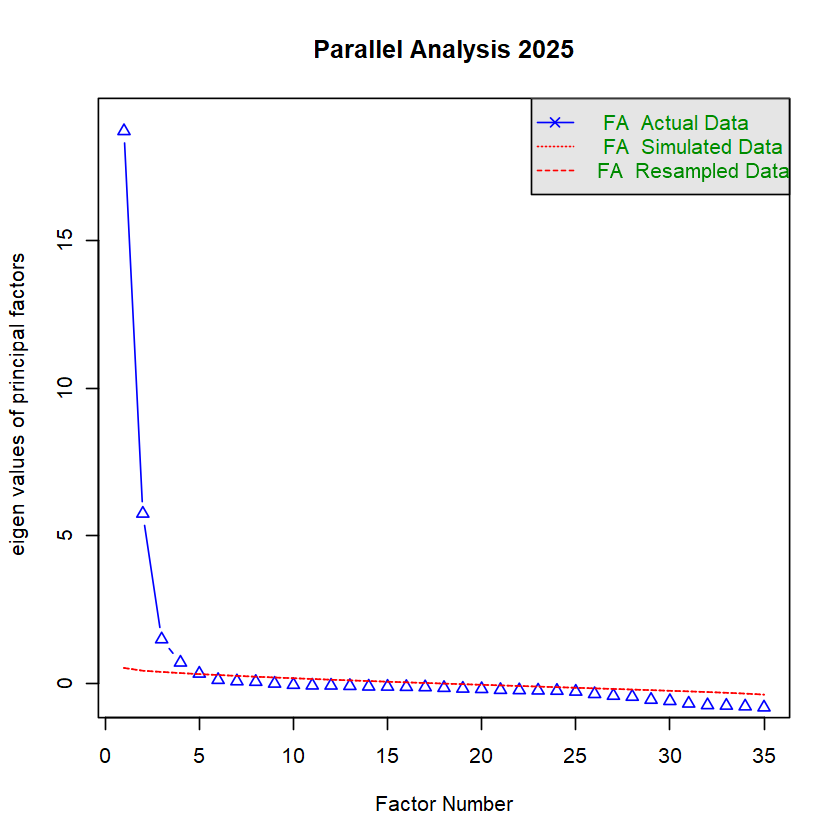

In [28]:
# =========================================================
# PARALLEL ANALYSIS BY YEAR
# =========================================================

years <- sort(
  unique(
    efa_data_raw$Version_Year
  )
)

for(y in years){

  cat("\n=====================\n")
  cat("YEAR:", y, "\n")
  cat("=====================\n")

  temp <- efa_data_raw %>%
    filter(
      Version_Year == y
    ) %>%
    select(where(is.numeric)) %>%
    select(-Version_Year)

  temp <- temp %>%

      # remover colunas totalmente NA
      select(
        where(~ !all(is.na(.)))
      ) %>%
    
      # remover variância zero
      select(
        where(~ {
          s <- sd(., na.rm = TRUE)
          !is.na(s) && s > 0
        })
      )

  fa.parallel(
    temp,
    fa = "fa",
    fm = "minres",
    n.iter = 200,
    main = paste(
      "Parallel Analysis",
      y
    )
  )
}

### 7. VSS + MAP por Ano

In [33]:
# =========================================================
# VSS + MAP BY YEAR
# =========================================================

vss_years <- list()

for(y in years){

  cat("\n=====================\n")
  cat("YEAR:", y, "\n")
  cat("=====================\n")

  temp <- efa_data_raw %>%
    filter(
      Version_Year == y
    ) %>%
    select(where(is.numeric)) %>%
    select(-Version_Year)

  temp <- temp %>%
    mutate(
      across(
        everything(),
        ~ ifelse(
          is.na(.),
          median(., na.rm = TRUE),
          .
        )
      )
    )

  vss_temp <- VSS(
    temp,
    n = 6,
    rotate = "promax",
    fm = "minres",
    plot = FALSE
  )

  vss_years[[as.character(y)]] <- vss_temp

  cat(
    "MAP:",
    which.min(vss_temp$map),
    "\n"
  )
}


YEAR: 2017 
MAP: 6 

YEAR: 2019 
MAP: 5 

YEAR: 2021 
MAP: 6 

YEAR: 2023 
MAP: 6 

YEAR: 2025 
MAP: 5 
